# Évaluation du modèle IA — Détection d'anomalies réseau (SOC-IA)

**Projet** : Module IA de détection d'anomalies réseau, entraîné sur CICIDS2017
**Modèle retenu** : Autoencoder, 15 features, entraîné sur trafic bénin uniquement
**Seuil officiel** : MSE = 0.2512 (recalibré Jour 5 après correction du bug de pipeline `log1p`)

Ce notebook reproduit et documente l'évaluation réalisée dans `src/finalize_jour4_v2.py`
(script validé, non modifié dans sa logique — seule la structuration en notebook avec
visualisations change). Livrable attendu par le cahier des charges S2 :
*"Modèle IA entraîné + notebook d'évaluation (precision/recall)"*.

**Méthodologie de calibration du seuil** : percentile-based FPR sweep sur `val_benign`
(seuil fixé pour cibler un FPR de 14 % sur le set de validation bénin), puis validation
par bootstrap (30 itérations) sur le set de test mixte.

⚠️ **Point de vigilance à garder en tête pendant la lecture** : le Recall obtenu (85,01 %)
ne laisse qu'une marge de sécurité quasi nulle (0,01 pt) au-dessus de la cible 85 % fixée
par le cahier des charges. Ce n'est pas un résultat "confortable", à présenter honnêtement
dans le rapport.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import json
import tensorflow as tf
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os
sys.path.append(os.path.abspath("../src"))

from config import FEATURES, TARGET

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


I0000 00:00:1786897310.531270   23454 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786897310.531964   23454 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786897310.592042   23454 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786897312.088253   23454 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786897312.088713   23454 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Configuration et chargement des données

On charge les fichiers `*_scaled.parquet` **déjà régénérés après le fix du bug `log1p`**
(shift persisté sur `train_benign`, cf. Section 3 du document de reprise Jour 5) — jamais
les fichiers non transformés, pour rester cohérent avec le pipeline d'entraînement.

- `val_benign_scaled.parquet` : trafic bénin uniquement, utilisé pour calibrer le seuil
- `test_mixed_scaled.parquet` : trafic mixte (bénin + attaques), utilisé pour l'évaluation finale


In [2]:
DATA_DIR = "../data"
MODELS_DIR = "../models"
LOGS_DIR = "../logs"
RANDOM_STATE = 42
N_BOOTSTRAP = 30

val = pd.read_parquet(f"{DATA_DIR}/val_benign_scaled.parquet")
test = pd.read_parquet(f"{DATA_DIR}/test_mixed_scaled.parquet")

X_val = val[FEATURES].values.astype("float32")
X_test = test[FEATURES].values.astype("float32")
y_true = (test[TARGET] != "BENIGN").astype(int).values

print(f"Set de validation (bénin) : {X_val.shape[0]} lignes, {X_val.shape[1]} features")
print(f"Set de test (mixte)       : {X_test.shape[0]} lignes")
print(f"Dont attaques réelles     : {y_true.sum()} ({y_true.mean()*100:.2f}%)")


Set de validation (bénin) : 227310 lignes, 15 features
Set de test (mixte)       : 784956 lignes
Dont attaques réelles     : 557646 (71.04%)


## 3. Chargement du modèle

Autoencoder entraîné exclusivement sur du trafic bénin (`train_benign`). Le principe :
un flux bénin est bien reconstruit (MSE faible), un flux anormal est mal reconstruit
(MSE élevé) car le modèle n'a jamais vu ce type de pattern à l'entraînement.


In [3]:
model = tf.keras.models.load_model(f"{MODELS_DIR}/autoencoder.keras")
model.summary()


E0000 00:00:1786897314.171642   23454 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139 (4.45 KB)

 Trainable params: 379 (1.48 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 760 (2.97 KB)

## 4. Calcul de l'erreur de reconstruction (MSE)

On calcule le MSE de reconstruction sur les deux sets : `val` sert à calibrer le seuil,
`test` sert à l'évaluation finale (jamais utilisé pour choisir le seuil, pour éviter la
fuite de données).


In [4]:
val_pred = model.predict(X_val, verbose=0)
val_mse = np.mean(np.square(X_val - val_pred), axis=1)

test_pred = model.predict(X_test, verbose=0)
test_mse = np.mean(np.square(X_test - test_pred), axis=1)

print(f"MSE validation (bénin)  : moyenne={val_mse.mean():.4f} | médiane={np.median(val_mse):.4f}")
print(f"MSE test (mixte)        : moyenne={test_mse.mean():.4f} | médiane={np.median(test_mse):.4f}")


MSE validation (bénin)  : moyenne=0.1220 | médiane=0.0514
MSE test (mixte)        : moyenne=0.3141 | médiane=0.3400


## 5. Calibration du seuil (percentile-based FPR sweep)

Le seuil est fixé au percentile du MSE de validation (bénin) correspondant à un FPR
cible de 14 %. Concrètement : `THRESHOLD = percentile(val_mse, 100 - 14.0)` — c'est-à-dire
la valeur de MSE en dessous de laquelle se trouvent 86 % des flux bénins de validation.

**Seuil officiel retenu (recalibré Jour 5) : MSE = 0.2512**


In [5]:
THRESHOLD = np.percentile(val_mse, 100 - 14.0)
y_pred = (test_mse > THRESHOLD).astype(int)

print(f"Seuil MSE retenu : {THRESHOLD:.4f}")
assert abs(THRESHOLD - 0.2512) < 0.001, "Le seuil recalculé diverge du seuil officiel documenté !"
print("Seuil cohérent avec la valeur officielle documentée (0.2512).")


Seuil MSE retenu : 0.2512
Seuil cohérent avec la valeur officielle documentée (0.2512).


## 6. Visualisation — Distribution du MSE et seuil de décision

Le graphique ci-dessous montre où se situe le seuil par rapport à la distribution du MSE
sur le trafic bénin (validation) et sur le trafic de test mixte.


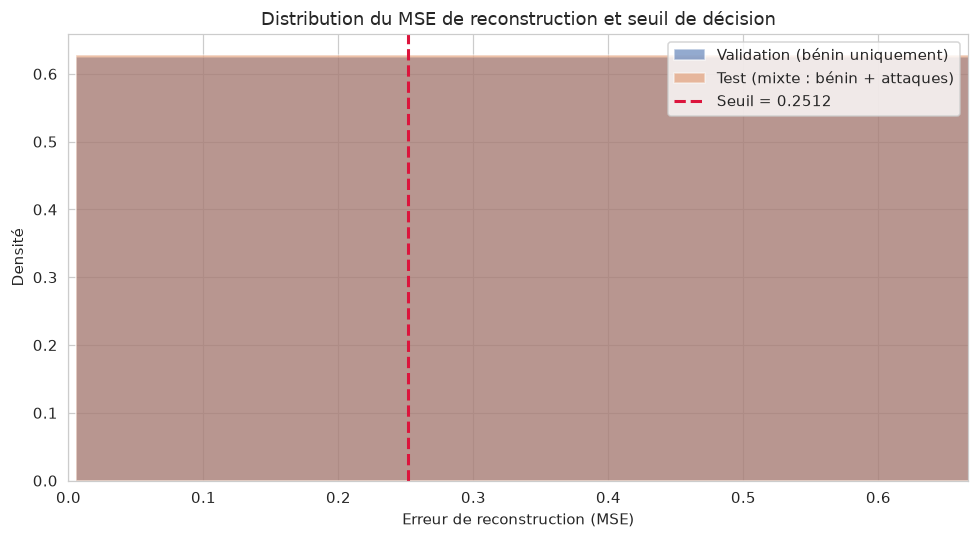

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(val_mse, bins=60, alpha=0.6, label="Validation (bénin uniquement)", color="#4C72B0", density=True)
ax.hist(test_mse, bins=60, alpha=0.5, label="Test (mixte : bénin + attaques)", color="#DD8452", density=True)
ax.axvline(THRESHOLD, color="crimson", linestyle="--", linewidth=2, label=f"Seuil = {THRESHOLD:.4f}")

ax.set_xlim(0, np.percentile(test_mse, 99))
ax.set_xlabel("Erreur de reconstruction (MSE)")
ax.set_ylabel("Densité")
ax.set_title("Distribution du MSE de reconstruction et seuil de décision")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Métriques globales (Recall / Precision / F1 / FPR)

Métriques calculées sur le set de test mixte, avec le seuil calibré ci-dessus.


In [7]:
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
fpr = fp / (fp + tn)

print("=== SEUIL FINAL RETENU — Autoencoder (15 features, chemin B) ===")
print(f"Features: {FEATURES}")
print(f"Seuil (MSE): {THRESHOLD:.4f}")
print(f"Recall: {recall*100:.2f}% | Precision: {precision*100:.2f}% | F1: {f1*100:.2f}% | FPR: {fpr*100:.2f}%")
print(f"TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")

print()
print(f"Conformité Recall >= 85% : {recall >= 0.85} (marge : {(recall-0.85)*100:+.2f} pt)")
print(f"Conformité FPR <= 15%    : {fpr <= 0.15} (marge : {(0.15-fpr)*100:+.2f} pt)")


=== SEUIL FINAL RETENU — Autoencoder (15 features, chemin B) ===
Features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Flow IAT Mean', 'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'FIN Flag Count', 'PSH Flag Count', 'Flow Bytes/s', 'Flow Packets/s', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Packet Length Std']
Seuil (MSE): 0.2512
Recall: 85.01% | Precision: 93.73% | F1: 89.15% | FPR: 13.95%
TP: 474028 | FP: 31712 | FN: 83618 | TN: 195598

Conformité Recall >= 85% : True (marge : +0.01 pt)
Conformité FPR <= 15%    : True (marge : +1.05 pt)


## 8. Visualisation — Matrice de confusion

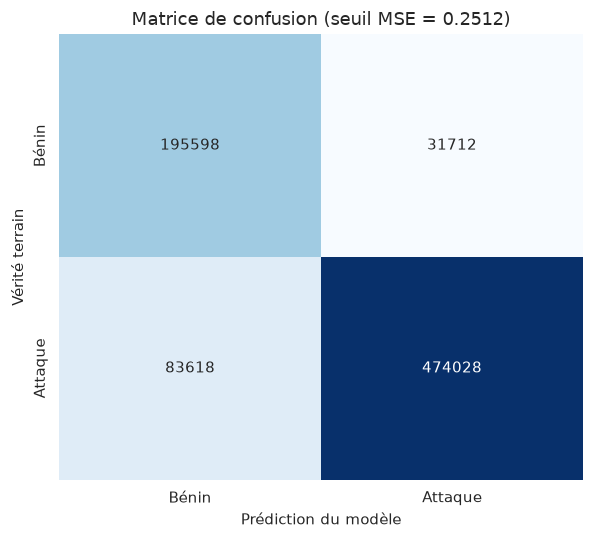

In [8]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Bénin", "Attaque"], yticklabels=["Bénin", "Attaque"], ax=ax)
ax.set_xlabel("Prédiction du modèle")
ax.set_ylabel("Vérité terrain")
ax.set_title(f"Matrice de confusion (seuil MSE = {THRESHOLD:.4f})")
plt.tight_layout()
plt.show()


## 9. Recall par type d'attaque

Le Recall global masque une forte hétérogénéité selon le type d'attaque (ex. DDoS
historiquement plus difficile à détecter que XSS pour ce modèle). Détail ci-dessous.


In [9]:
import re
df = test.copy()
df["predicted"] = y_pred
attack_only = df[df[TARGET] != "BENIGN"]
grouped = attack_only.groupby(TARGET).agg(total=(TARGET, "count"), detected=("predicted", "sum"))
grouped["recall_pct"] = (grouped["detected"] / grouped["total"] * 100).round(2)
grouped = grouped.sort_values("total", ascending=False)
grouped.index = [re.sub(r"[^\x00-\x7F]+", " - ", label) for label in grouped.index]

print("Recall par type d'attaque (seuil final, 15 features):")
print(grouped.to_string())


Recall par type d'attaque (seuil final, 15 features):
                               total  detected  recall_pct
DoS Hulk                      231073    213294       92.31
PortScan                      158930    156860       98.70
DDoS                          128027     83465       65.19
DoS GoldenEye                  10293      2953       28.69
FTP-Patator                     7938      3965       49.95
SSH-Patator                     5897      2937       49.80
DoS slowloris                   5796      3569       61.58
DoS Slowhttptest                5499      4093       74.43
Bot                             1966       861       43.79
Web Attack  -  Brute Force      1507      1356       89.98
Web Attack  -  XSS               652       628       96.32
Infiltration                      36        28       77.78
Web Attack  -  Sql Injection      21         9       42.86
Heartbleed                        11        10       90.91


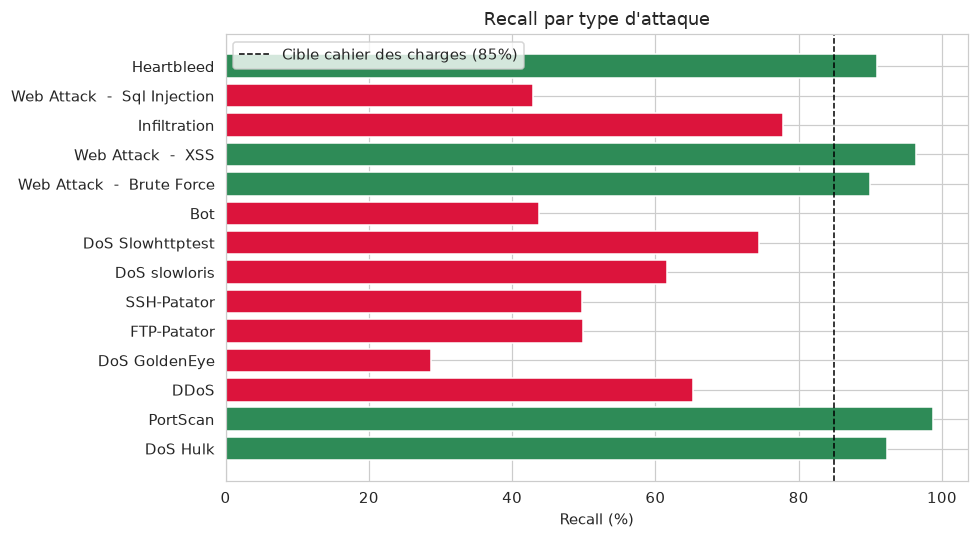

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["crimson" if v < 85 else "seagreen" for v in grouped["recall_pct"]]
ax.barh(grouped.index, grouped["recall_pct"], color=colors)
ax.axvline(85, color="black", linestyle="--", linewidth=1, label="Cible cahier des charges (85%)")
ax.set_xlabel("Recall (%)")
ax.set_title("Recall par type d'attaque")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Validation par bootstrap (30 itérations)

On ré-échantillonne le set de test (avec remise) 30 fois pour estimer la variance des
métriques et vérifier que le résultat n'est pas un artefact d'un tirage particulier.


In [11]:
recalls, precisions, f1s, fprs = [], [], [], []
idx = np.arange(len(y_true))

for i in range(N_BOOTSTRAP):
    s = resample(idx, replace=True, random_state=RANDOM_STATE + i)
    yt, yp = y_true[s], y_pred[s]
    recalls.append(recall_score(yt, yp, zero_division=0))
    precisions.append(precision_score(yt, yp, zero_division=0))
    f1s.append(f1_score(yt, yp, zero_division=0))
    tn_, fp_, fn_, tp_ = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    fprs.append(fp_ / (fp_ + tn_) if (fp_ + tn_) > 0 else 0)

print(f"Bootstrap ({N_BOOTSTRAP} itérations):")
print(f"  Recall:    {np.mean(recalls):.4f} +/- {np.std(recalls):.4f}")
print(f"  Precision: {np.mean(precisions):.4f} +/- {np.std(precisions):.4f}")
print(f"  F1:        {np.mean(f1s):.4f} +/- {np.std(f1s):.4f}")
print(f"  FPR:       {np.mean(fprs):.4f} +/- {np.std(fprs):.4f}")


Bootstrap (30 itérations):
  Recall:    0.8500 +/- 0.0005
  Precision: 0.9373 +/- 0.0004
  F1:        0.8915 +/- 0.0004
  FPR:       0.1395 +/- 0.0009


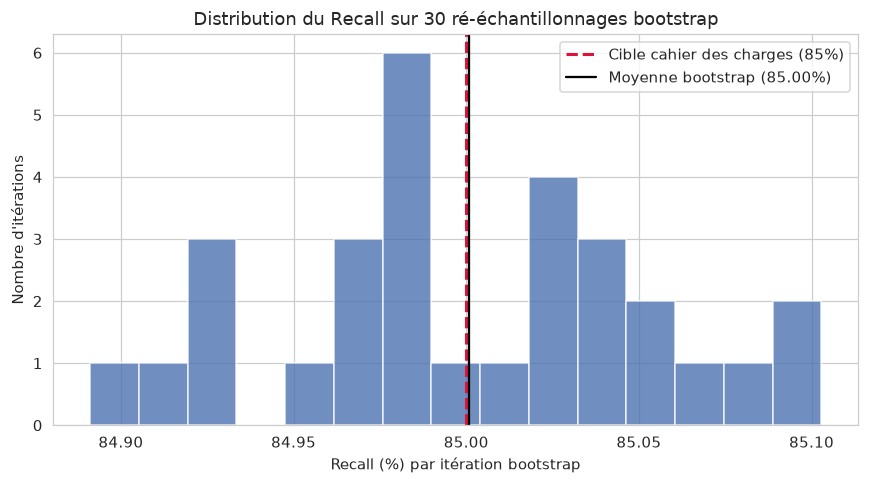

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(np.array(recalls) * 100, bins=15, color="#4C72B0", alpha=0.8)
ax.axvline(85, color="crimson", linestyle="--", linewidth=2, label="Cible cahier des charges (85%)")
ax.axvline(np.mean(recalls) * 100, color="black", linestyle="-", linewidth=1.5, label=f"Moyenne bootstrap ({np.mean(recalls)*100:.2f}%)")
ax.set_xlabel("Recall (%) par itération bootstrap")
ax.set_ylabel("Nombre d'itérations")
ax.set_title("Distribution du Recall sur 30 ré-échantillonnages bootstrap")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Estimation du volume d'alertes (indicatif)

⚠️ Indicateur **provisoire** : donne un ordre de grandeur du facteur de réduction du
volume d'alertes par rapport au nombre réel d'attaques, à affiner en conditions réelles
en S3 (le trafic de test CICIDS2017 n'est pas représentatif du volume/de la distribution
d'un flux réseau de production).


In [13]:
n_attacks_real = int(y_true.sum())
n_alerts_model = int(y_pred.sum())
factor = n_attacks_real / n_alerts_model if n_alerts_model > 0 else float("inf")

print(f"[PROVISOIRE] Attaques réelles: {n_attacks_real} | Alertes levées: {n_alerts_model} | Facteur: {factor:.2f}")


[PROVISOIRE] Attaques réelles: 557646 | Alertes levées: 505740 | Facteur: 1.10


## 12. Sauvegarde des résultats finaux (JSON)

In [14]:
final_results = {
    "version": "v2_chemin_B_15_features",
    "model_retenu": "Autoencoder",
    "features": FEATURES,
    "feature_ajoutee": "Packet Length Std",
    "seuil_mse": float(THRESHOLD),
    "fpr_cible_pct": 14.0,
    "recall": float(recall),
    "precision": float(precision),
    "f1": float(f1),
    "fpr_reel": float(fpr),
    "recall_target_cdc": 0.85,
    "conforme_recall": bool(recall >= 0.85),
    "fpr_target_cdc_max": 0.15,
    "conforme_fpr": bool(fpr <= 0.15),
    "conforme_global": bool(recall >= 0.85 and fpr <= 0.15),
    "recall_par_attaque": grouped["recall_pct"].to_dict(),
    "bootstrap": {
        "recall_mean": float(np.mean(recalls)), "recall_std": float(np.std(recalls)),
        "fpr_mean": float(np.mean(fprs)), "fpr_std": float(np.std(fprs)),
    },
    "volume_reduction_factor_provisional": factor,
}

with open(f"{LOGS_DIR}/jour4_final_threshold_v2.json", "w") as f:
    json.dump(final_results, f, indent=2)

print(f"Résultats sauvegardés : {LOGS_DIR}/jour4_final_threshold_v2.json")


Résultats sauvegardés : ../logs/jour4_final_threshold_v2.json


## 13. Conclusion et limites connues

**Résultats finaux (seuil MSE = 0,2512, recalibré Jour 5 après correction du bug `log1p`)** :

| Métrique | Valeur |
|---|---|
| Recall | 85,01 % |
| Precision | 93,73 % |
| F1 | 89,15 % |
| FPR | 13,95 % |

**Limites connues (à assumer explicitement dans le rapport de stage) :**

- **Marge de sécurité quasi nulle sur le Recall** : 0,01 point au-dessus de la cible 85 %
  fixée par le cahier des charges. Ce n'est pas un résultat confortable, et toute dérive
  du trafic réel en S3/S4 pourrait faire repasser le Recall sous la cible.
- **Forte hétérogénéité du Recall selon le type d'attaque** : 65,18 % sur DDoS contre
  96,32 % sur XSS (voir Section 9 et `logs/jour4_final_threshold_v2.json` pour le détail
  complet par catégorie).
- **Imputation NaN/inf non gérée en inférence** : en production (API `src/api_scoring.py`),
  une requête contenant une valeur non finie est rejetée plutôt qu'imputée, car la médiane
  d'imputation d'entraînement n'a pas été persistée (décision méthodologique Jour 5).
- **Facteur de réduction du volume d'alertes** encore provisoire : à réévaluer en S3 sur
  un flux réseau réel, le dataset CICIDS2017 n'étant pas représentatif d'un environnement
  de production en termes de volume et de distribution du trafic.

Ce notebook clôture le livrable "évaluation" du cahier des charges S2. Prochaine étape :
rédaction du compte-rendu court pour le rapport de stage (Section 3 du document de reprise
Jour 5), puis clôture officielle de la S2.
